# Documentation of the method to detect interfaces
This notebook describes the method that is used to detect air-snow, snow-ice, and ice-water interfaces from the thermistor string-based temperature data. 

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cmocean.cm as cmo

In [230]:
data = xr.open_dataset("test_data.nc")

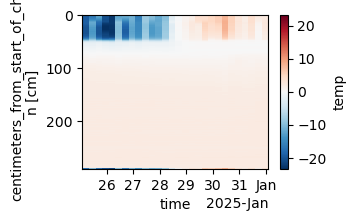

In [231]:
plt.figure(figsize=(3,2))
data.temp.plot(y="pos", yincrease=False)

In [166]:
# These variables are computed or stored in files in a real-world application. Here we manually define them for the simplicity of the example
frozen = True
isurf = 20
frozendate = "2026-01-15"

First consider a case where the air temperature is negative

In [232]:
d = 4
da = data.isel(time=d, pos=slice(None, -1))

In [233]:
dTdz = da.temp.differentiate("pos")
d2Tdz2 = dTdz.differentiate("pos")

In [240]:
l0 = -25
u0 = 4
l1 = -0.3
u1 = 3
l2 = -0.4
u2 = 0.4

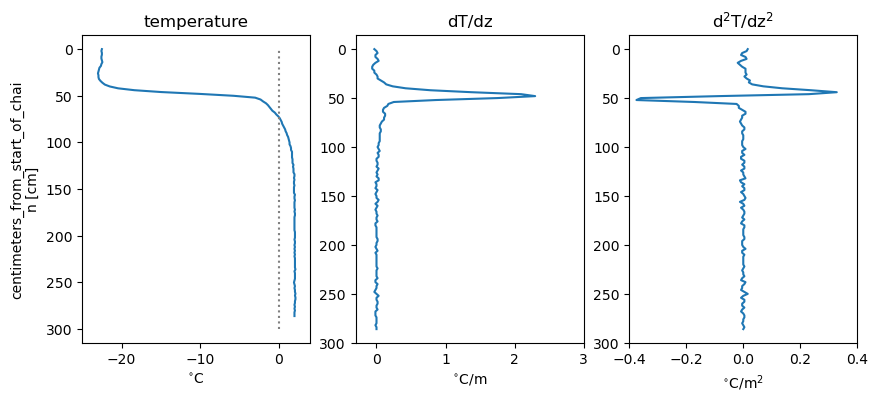

In [241]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")

In [242]:
iiceBot = xr.where(da.temp < 0, True, False)[::-1].cumsum("pos")[::-1].argmin("pos") 
iceBot = da.pos[iiceBot].where(((iiceBot != 0) & (iiceBot >= isurf)), other=da.pos.isel(pos=isurf).values)

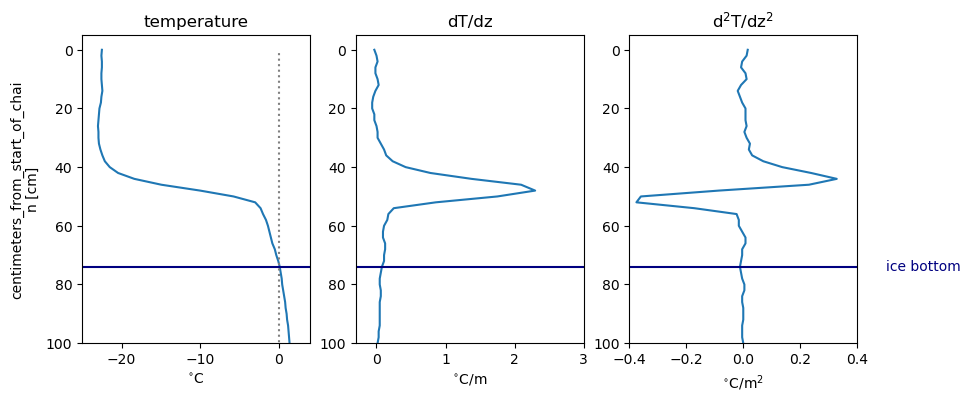

In [243]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

First detect *anywhere* in the snow pack and then the top of the snow

In [244]:
isnowMid = dTdz.where(((da.pos < iceBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)

In [245]:
isnowTop = xr.where(((da.pos < snowMid) & (dTdz < (0.2 * dTdz.max("pos"))) & (da.temp <= 0)), True, False)[::-1].cumsum("pos")[::-1].argmin("pos")
snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)

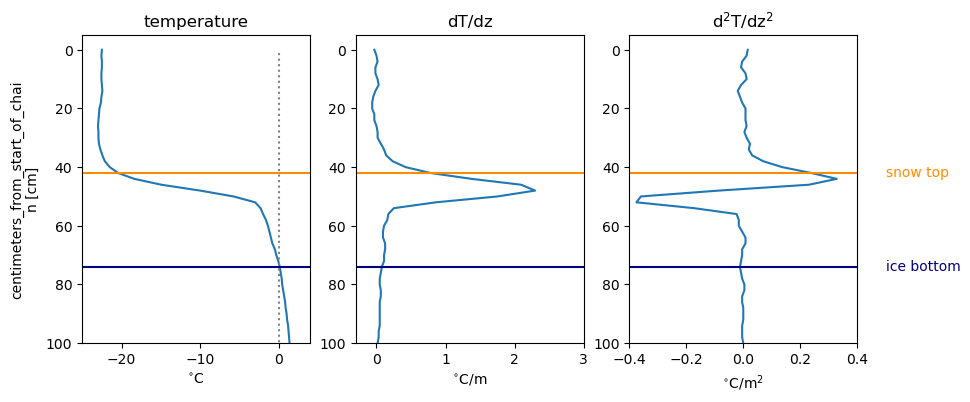

In [246]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="darkorange", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="darkorange", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="darkorange")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

In [247]:
isnowBot = xr.where(((da.pos >= snowTop) & (da.pos <= iceBot) & (da.temp <= 0) 
                     & (d2Tdz2 < (0.5 * d2Tdz2.min("pos")))), True, False).cumsum("pos").argmax("pos")
snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)

iiceTop1st = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)

iiceTop = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0)), other=0).argmin(dim="pos")
iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)

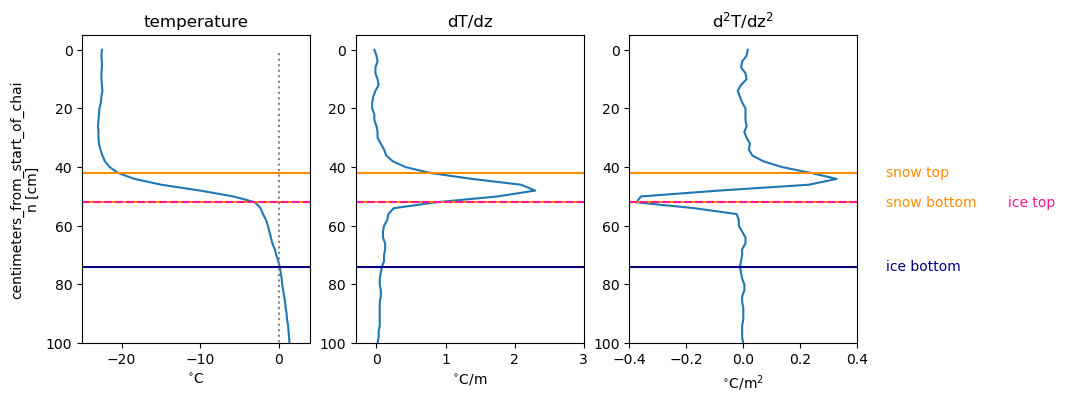

In [248]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="darkorange", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowBot), l0, u0, color="darkorange", ls="-")
ax[0].hlines(da.pos.isel(pos=iiceTop), l0, u0, color="deeppink", ls="--")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="darkorange", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowBot), l1, u1, color="darkorange", ls="-")
ax[1].hlines(da.pos.isel(pos=iiceTop), l1, u1, color="deeppink", ls="--")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="darkorange")
ax[2].hlines(da.pos.isel(pos=isnowBot), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowBot), "snow bottom", va="center", ha="left", color="darkorange")
ax[2].hlines(da.pos.isel(pos=iiceTop), l2, u2, color="deeppink", ls="--")
ax[2].text(u2 + 0.53, da.pos.isel(pos=iiceTop), "ice top", va="center", ha="left", color="deeppink")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

Next a case where air temperature is positive

In [312]:
d = 16
da = data.isel(time=d, pos=slice(None, -1))

In [313]:
dTdz = da.temp.differentiate("pos")
d2Tdz2 = dTdz.differentiate("pos")

In [314]:
l0 = -1
u0 = 12
l1 = -1
u1 = 0.2
l2 = -0.3
u2 = 0.3

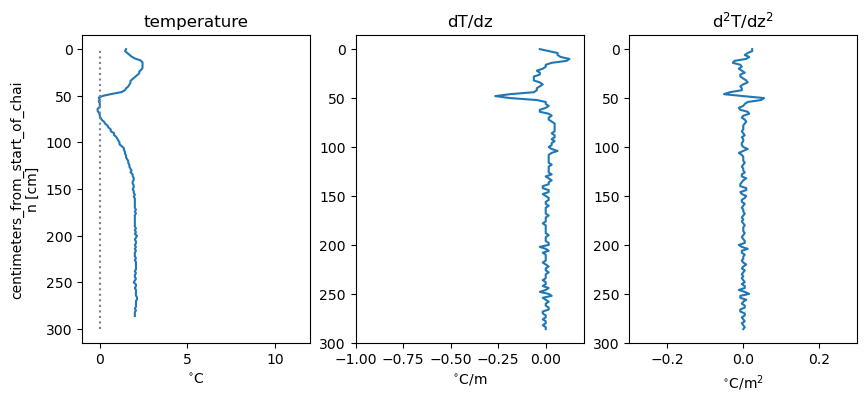

In [315]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")

In [316]:
iiceBot = xr.where(da.temp < 0, True, False)[::-1].cumsum("pos")[::-1].argmin("pos") 
iceBot = da.pos[iiceBot].where(((iiceBot != 0) & (iiceBot >= isurf)), other=da.pos.isel(pos=isurf).values)

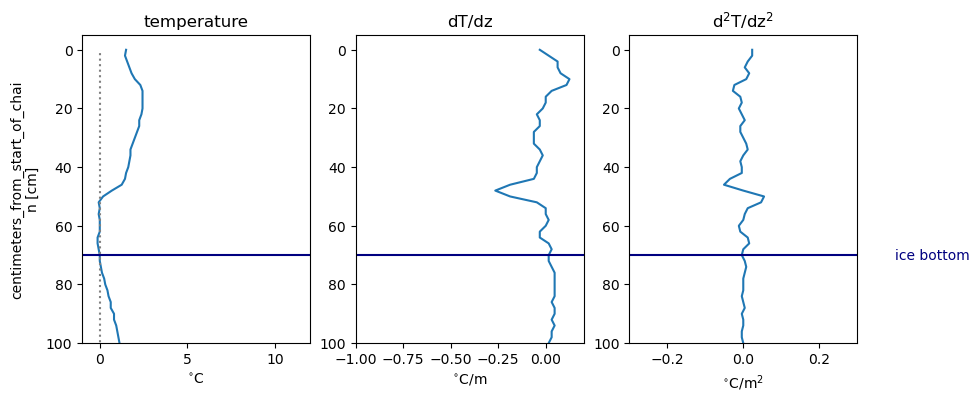

In [317]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

First detect *anywhere* in the snow pack and then the top of the snow

In [318]:
isnowMid = dTdz.where(((da.pos < iceBot)), other=0).argmin(dim="pos")
snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)

In [319]:
isnowTop = xr.where(((da.pos < snowMid) & (dTdz > (0.2 * dTdz.min("pos")))), True, False)[::-1].cumsum("pos")[::-1].argmin("pos")
snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)

In [334]:
(da.pos < snowMid)

<xarray.DataArray 'pos' (pos: 144)> Size: 144B
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False])
Coordinates:
  * pos      (pos) int64 1kB 0 2 4 6 8 10 12 14 ... 274 276 278 280 282 284 286
    time     datetime64[ns] 8B 2024-12-29T05:00:18

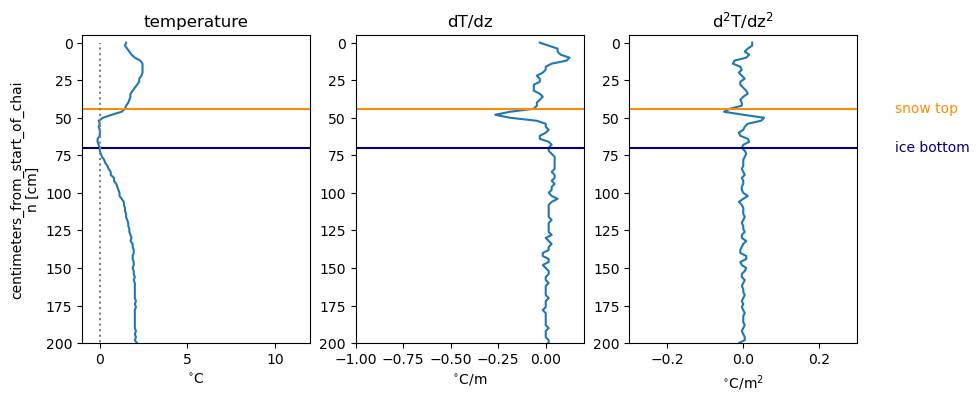

In [320]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="darkorange", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="darkorange", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="darkorange")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(200, -5)

In [321]:
isnowBot = xr.where(((da.pos >= snowTop) & (da.pos <= iceBot)
                         & (d2Tdz2 > (0.5 * d2Tdz2.max("pos")))), True, False).cumsum("pos").argmax("pos")
snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)

In [322]:
iiceTop1st  = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmin(dim="pos") 
iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)
iiceTop  = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0)), other=0).argmax(dim="pos") 
iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)

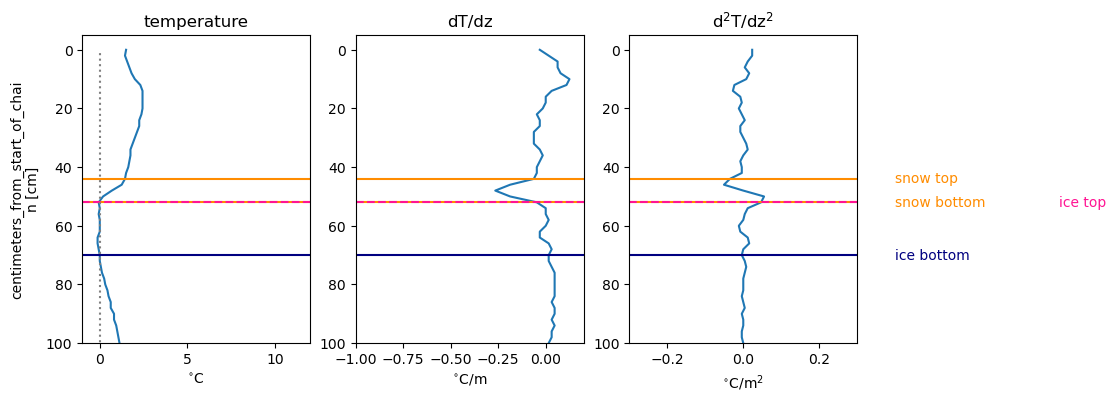

In [323]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="darkorange", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowBot), l0, u0, color="darkorange", ls="-")
ax[0].hlines(da.pos.isel(pos=iiceTop), l0, u0, color="deeppink", ls="--")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="darkorange", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowBot), l1, u1, color="darkorange", ls="-")
ax[1].hlines(da.pos.isel(pos=iiceTop), l1, u1, color="deeppink", ls="--")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="darkorange")
ax[2].hlines(da.pos.isel(pos=isnowBot), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowBot), "snow bottom", va="center", ha="left", color="darkorange")
ax[2].hlines(da.pos.isel(pos=iiceTop), l2, u2, color="deeppink", ls="--")
ax[2].text(u2 + 0.53, da.pos.isel(pos=iiceTop), "ice top", va="center", ha="left", color="deeppink")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

Put everything into a function that does the detection on a timeseries

In [2]:
def detect_interfaces(da, t_air, isurf, frozendate):
    '''Detect air-snow, snow-ice, and ice-water interfaces in temperature profile. Developed 
    for use with thermistor string data from a SAMS Enterprise Snow and Ice Mass Balance Apparatus (SIMBA)
    and NOT tested with any other data.

    Parameters
    ----------
    da : xarray Dataset
        2D xarray Dataset created by `convert-buoy-data` (https://github.com/McGill-sea-ice/convert-buoy-data)
        Dimensions are `time` and `pos` (position along thermistor string) and the temperature variable
        must be named `temp`. The last index along `pos` (air temperature) has to be removed.

    t_air : xarray DataArray
        1D xarray DataArray containing the air temperature associated with `da` (the last index along `pos`
        in the original dataset)

    isurf : int
        Integer describing at which index along `pos` the initial (non-frozen) water-air interface is located.

    forzendate : str
        Date on which the water first froze. Format is "YYYY-MM-DD"

    Returns
    -------
    idx : dict
        Dictionary containing the keys ("snowTop", "snowMid", "snowBot", "iceTop", "iceBot"), each with a
        time series of the indeces of the air-snow interface, the mid-point of the snow cover, the bottom
        of the snow cover, the top of the ice, and the ice-water interface. 

    dep : dict
        Same as `idx` but containing the "depths", i.e. the distance in cm along the thermistor string for
        each variable instead of the indeces.
    '''
    # Create boolean, True when air temperature is > 0
    t_air_gt_0 = (t_air >= 0).compute()
    # Get first and second vertical derivative
    dTdz = da.temp.differentiate("pos")
    d2Tdz2 = dTdz.differentiate("pos")
    # GENERAL: most interface detections apply some simple sanity checks like "snow temperature must be
    # below zero", "ice bottom must be below snow bottom", etc. In the following, those will not be 
    # commented.
    #
    # ice-water interface (bottom of the ice) is where temperature drops below zero for the first
    # time when starting from the bottom of the thermistor string
    iiceBot = xr.where(da.temp < 0, True, False)[:, ::-1].cumsum("pos")[:, ::-1].argmin("pos") 
    iceBot = da.pos[iiceBot].where(((iiceBot != 0) & (iiceBot >= isurf)), other=da.pos.isel(pos=isurf).values)
    # the maximum of the first derivative is located in the snow
    isnowMid = dTdz.where(((da.pos < iceBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
    snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)
    # the top of the snow is where the first derivative drops below 0.2 times its maximum value
    # for the first time when going upwards, starting for the middle of the snow pack
    isnowTop = xr.where(((da.pos < snowMid) & (dTdz < (0.2 * dTdz.max("pos"))) & (da.temp <= 0)), True, False)[::-1, :].cumsum("pos")[::-1, :].argmin("pos")
    snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)
    # the bottom of the snow is where the second derivative drops below 0.5 times its minimum
    # value looking down
    isnowBot = xr.where(((da.pos >= snowTop) & (da.pos <= iceBot) & (da.temp <= 0) 
                         & (d2Tdz2 < (0.5 * d2Tdz2.min("pos")))), True, False).cumsum("pos").argmax("pos")
    snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)
    # for the ice top, first find the maximum first derivative below the snow bottom
    iiceTop1st = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
    iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)
    # the mimimum of the second derivative below the maximum of the first derivative
    # is the ice top (in most cases snow bottom == ice top)
    iiceTop = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0)), other=0).argmin(dim="pos")
    iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)
    # redo for air temperatures >= 0 because most of the gradients reverse in that case
    # but the algorithm still works quite well unless temperature is close to zero
    isnowMid[t_air_gt_0] = dTdz.where(((da.pos < iceBot) & (da.temp <= 0)), other=0).argmin(dim="pos")[t_air_gt_0]
    snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)
    isnowTop[t_air_gt_0] = xr.where(((da.pos < snowMid) & (dTdz > (0.2 * dTdz.min("pos"))) & (da.temp <= 0)), True, False)[::-1, :].cumsum("pos")[::-1, :].argmin("pos")[t_air_gt_0]
    snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)
    isnowBot[t_air_gt_0] = d2Tdz2.where(((da.pos >= snowTop) & (da.pos <= iceBot) & (da.temp <= 0)
                                        & (d2Tdz2 > (0.5 * d2Tdz2.max("pos")))), True, False).cumsum("pos").argmax("pos")[t_air_gt_0]
    snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)
    iiceTop1st[t_air_gt_0]  = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmin(dim="pos")[t_air_gt_0] 
    iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)
    iiceTop[t_air_gt_0]  = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0)), other=0).argmax(dim="pos")[t_air_gt_0] 
    iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)
    # set everything to NaN before the freezing date
    iiceBot = iiceBot.where(iiceBot.time > np.datetime64(frozendate), other=np.nan)
    iceBot = iceBot.where(iceBot.time > np.datetime64(frozendate), other=np.nan)
    iiceTop = iiceTop.where(iiceTop.time > np.datetime64(frozendate), other=np.nan)
    iceTop = iceTop.where(iceTop.time > np.datetime64(frozendate), other=np.nan)
    isnowBot = isnowBot.where(isnowBot.time > np.datetime64(frozendate), other=np.nan)
    snowBot = snowBot.where(snowBot.time > np.datetime64(frozendate), other=np.nan)
    isnowMid = isnowMid.where(isnowMid.time > np.datetime64(frozendate), other=np.nan)
    snowMid = snowMid.where(snowMid.time > np.datetime64(frozendate), other=np.nan)
    isnowTop = isnowTop.where(isnowTop.time > np.datetime64(frozendate), other=np.nan)
    snowTop = snowTop.where(snowTop.time > np.datetime64(frozendate), other=np.nan)
    # get d/dt of ice top, if interface changes too much within one day, the algorithm likely failed and we take the values from the day before or after
    ddticeTop = np.zeros(len(iceTop))
    ddticeTop[1::] = iceTop.values[1::] - iceTop.values[0:-1]
    t = 1
    while t < len(iceTop):
        if np.abs(ddticeTop[t]) > 20:
            if t == len(iceTop) - 1:
                iceTop[t] = iceTop[t-1]
                t += 1
            else:
                tt = t
                while ((iceTop[tt] > iceTop[t-1] + 20) | (iceTop[tt] < iceTop[t-1] - 20)):
                    tt += 1
                iceTop[t:tt] = np.interp(np.arange(t, tt), [t-1, tt], [iceTop[t-1].values, iceTop[tt].values])
                t = tt + 1
        else:
            t += 1
    # redo snow bottom and top after corrections to ice top (they cannot be below ice top)
    snowTop[(snowTop > iceTop).compute()] = iceTop[(snowTop > iceTop).compute()]
    snowBot[(snowBot > iceTop).compute()] = iceTop[(snowBot > iceTop).compute()]
    # set everything to NaN where temperature is NaN near the surface
    if frozendate != 0:
        yaxmax = int(np.max(isurf + iiceBot - isnowTop).values)
        if np.min(isnowTop) < 5:
            yaxmin = 5
        else:
            yaxmin = int(np.min(isnowTop).values)
    else:
        yaxmax = isurf+10
        yaxmin = isurf-10
    isnowTop = isnowTop.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    isnowMid = isnowMid.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    isnowBot = isnowBot.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    iiceTop = iiceTop.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    iiceBot = iiceBot.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    snowTop = snowTop.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    snowMid = snowMid.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    snowBot = snowBot.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    iceTop = iceTop.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    iceBot = iceBot.where(~np.isnan(da.temp.isel(pos=slice(yaxmin-5, yaxmax+6)).mean("pos")), other=np.nan)
    # create dictionaries with the computed variables
    idx = {"snowTop": isnowTop, "snowMid": isnowMid, "snowBot": isnowBot, "iceTop": iiceTop, "iceBot": iiceBot}
    dep = {"snowTop": snowTop, "snowMid": snowMid, "snowBot": snowBot, "iceTop": iceTop, "iceBot": iceBot}
    return idx, dep

In [8]:
idx, dep = detect_interfaces(data, t_air, isurf, frozendate)